implimentation of clustering problems 

In [9]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd 
import numpy as np 
%matplotlib inline 

In [5]:
x,y= make_blobs(n_samples=100,centers=3,n_features=2,random_state=23)

In [6]:
x.shape

(100, 2)

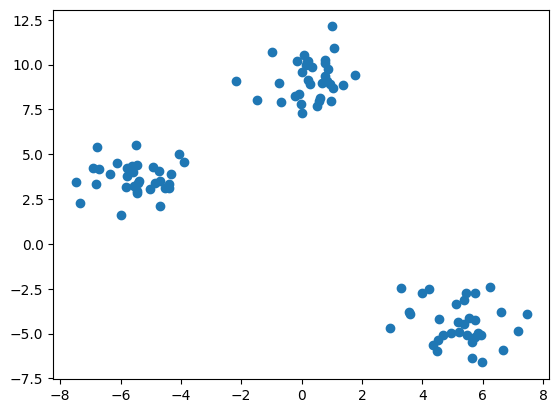

In [13]:
plt.scatter(x[:,0],x[:,1])

In [14]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(
    x,y, test_size=0.33,random_state=42)

In [15]:
from sklearn.cluster import KMeans

In [ ]:
##   Manual method: Elbow methods to select the k value
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters =k,init='k-means++')
    kmeans.fit(x_train)
    wcss.append(kmeans.inertia_) 

In [19]:
wcss

[3605.1367590848276,
 832.431390612043,
 124.19935535709938,
 100.92366316084953,
 91.57373610129119,
 77.34254695121527,
 58.324461548311604,
 51.507580997117174,
 44.52683018031557,
 43.87105831686148]

Now let's visulaise the elbow 

In [ ]:
#plot showing elbow curve 
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

In [21]:
kmeans=KMeans(n_clusters =3,init='k-means++')

In [22]:
y_lables=kmeans.fit_predict(x_train)

In [27]:
y_test_lables=kmeans.predict(x_test)

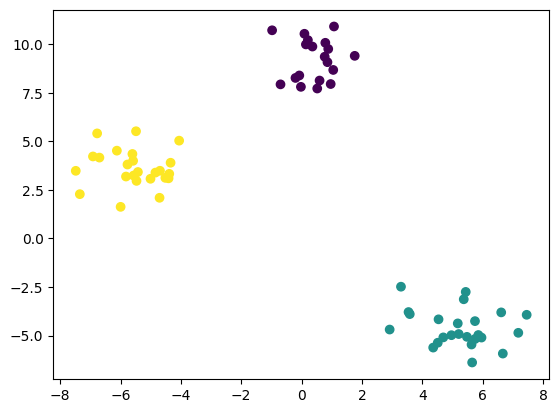

In [23]:
plt.scatter(x_train[:,0],x_train[:,1],c=y_lables)

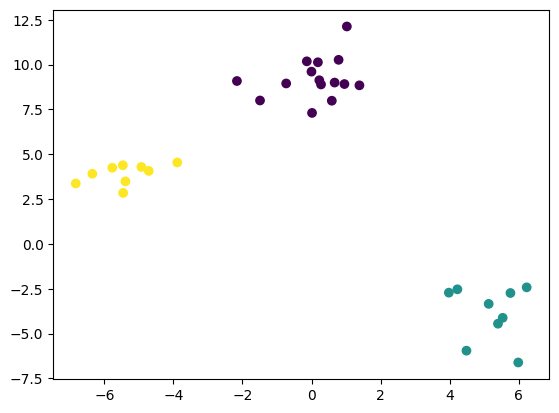

In [31]:
plt.scatter(x_test[:,0],x_test[:,1],c=y_test_lables)

for huge dataset applying clustering using manual way may not be feasalbe so to tackal such situations we can go for automated way using kneed library

In [34]:
from kneed import KneeLocator

In [ ]:
kl=KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')
kl.elbow ## it show the value of k automatically 

np.int64(3)

In [44]:
from sklearn.metrics import  silhouette_score


In [45]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters =k,init='k-means++')
    kmeans.fit(x_train)
    score=silhouette_score(x_train,kmeans.labels_)
    silhouette_coefficients.append(score)

In [46]:
silhouette_coefficients

[0.7221825607415234,
 0.8182367206056518,
 0.6690721746399169,
 0.5515447503856891,
 0.4983200193609981,
 0.3639364197648597,
 0.420419903582329,
 0.3823794103619968,
 0.40087636753371075]

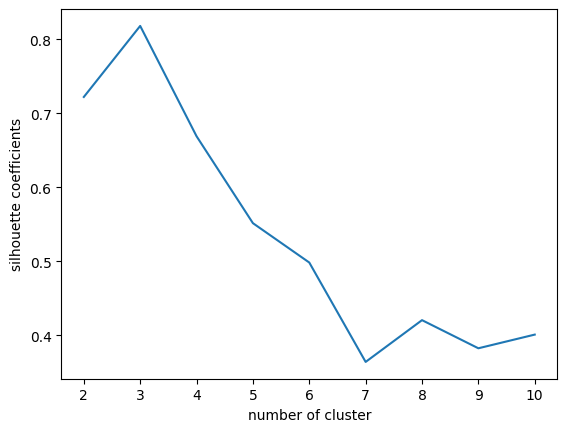

In [48]:
# ploting silhouette score 
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("number of cluster")
plt.ylabel("silhouette coefficients")
plt.show()